# 1. From a decay channel to a Dalitz plot

**Learning goals:** identify invariant coordinates, build a coherent model, and distinguish a weighted phase-space proposal from signal pseudo-data.

Run cells from top to bottom in a fresh Python kernel. Install the package and Jupyter
as explained in [the course guide](TUTORIALS.md). No external data files are needed.
Masses are in GeV, invariants in GeV², and daughter indices start at zero.
The small event counts and grid sizes keep this lesson practical on a CPU; they are
teaching settings, not a demonstrated precision choice for a physics analysis.

In [1]:
from dalitzplotfitter import enable_x64
enable_x64()  # Must precede numerical work: amplitudes use complex128.

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from dalitzplotfitter import (
    DecayChannel, DecayModel, FitSession, NonResonant,
    Parameter, RealImag, Resonance, generate_toy,
)

## Choose the particles and the amplitude

For `D+ -> pi- pi+ pi+`, `s12` is the squared mass of daughters 0 and 1;
`s13` uses 0 and 2, and `s23` uses 1 and 2. Thus `pair=(0, 1)` selects `s12`.
The two positive pions are identical: the model symmetrizes the resonance automatically.

We use an illustrative rho plus constant S-wave model, not a published D-decay fit.
The amplitude is `A = F_rho + (x + i*y) F_NR`. Intensities are `abs(A)**2`,
so the components interfere. Fixing the rho coefficient to `1 + 0i` removes the
unobservable global phase and scale. Individual components have unit integral by default.

In [2]:
channel = DecayChannel("D+", ("pi-", "pi+", "pi+"))
x = Parameter.coefficient("NR.x", 0.55, owner="NR", bounds=(-2, 2), step=0.02)
y = Parameter.coefficient("NR.y", 0.30, owner="NR", bounds=(-2, 2), step=0.02)
components = [
    Resonance("rho", (0, 1), RealImag(1, 0), mass=0.7753, width=0.1491, spin=1),
    NonResonant(RealImag(x, y), name="NR"),
]
model = DecayModel(
    channel, components, normalization_method="square-dalitz",
    normalization_resolution=100, normalization_pair=(0, 1),
)
truth = {p.name: p.value for p in model.parameters}

## Inspect a weighted phase-space sample

`generate_phase_space` produces proposal events with integration weights. Use those
weights when visualizing phase-space integrals; the raw proposal histogram need not be flat.
The three invariants satisfy a useful event-by-event identity.

Events: 6000 Invariant dtype: float64
Mean integration weight: 0.00036334144690769926


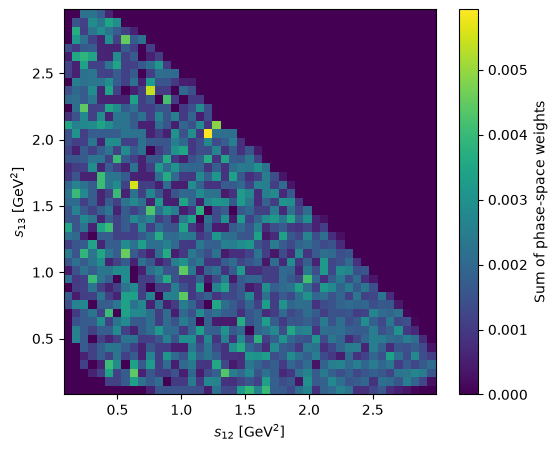

In [3]:
proposal = model.generate_phase_space(6000, seed=11, include_momenta=False)
expected_sum = channel.parent_mass**2 + sum(m**2 for m in channel.daughter_masses)
np.testing.assert_allclose(
    proposal.s12 + proposal.s13 + proposal.s23, expected_sum, rtol=1e-12,
)
print("Events:", proposal.size, "Invariant dtype:", proposal.s12.dtype)
print("Mean integration weight:", float(jnp.mean(proposal.weights)))
fig, ax = plt.subplots(figsize=(6, 5))
h = ax.hist2d(np.asarray(proposal.s12), np.asarray(proposal.s13),
              weights=np.asarray(proposal.weights), bins=45)
fig.colorbar(h[3], ax=ax, label="Sum of phase-space weights")
ax.set(xlabel=r"$s_{12}$ [GeV$^2$]", ylabel=r"$s_{13}$ [GeV$^2$]")
plt.show()

## Generate observed signal-like events

Signal toys follow the coherent intensity and have unit event weights. They can be fitted
as unweighted observations. They are **not** unit-weight normalization samples.
Inverse-transform generation tabulates CDFs; raising its resolution controls a separate
approximation from the fit integration grid.

In [4]:
data = generate_toy(
    model, 2500, parameters=truth, seed=2026,
    method="inverse-transform", inverse_resolution=384, include_momenta=False,
)
print(f"Generated {data.size} unweighted events")
assert np.all(np.asarray(data.weights) == 1)

Generated 2500 unweighted events


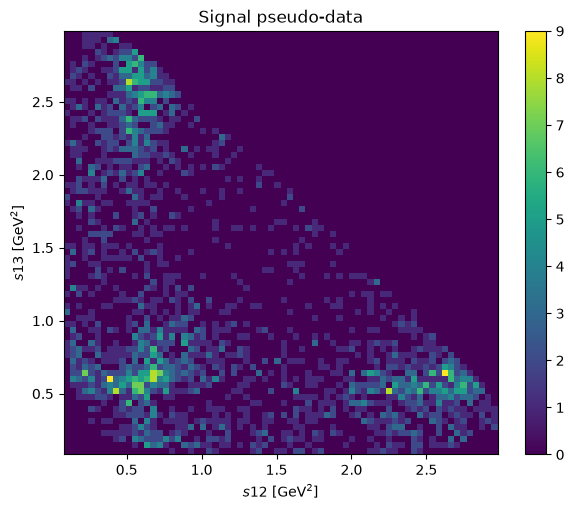

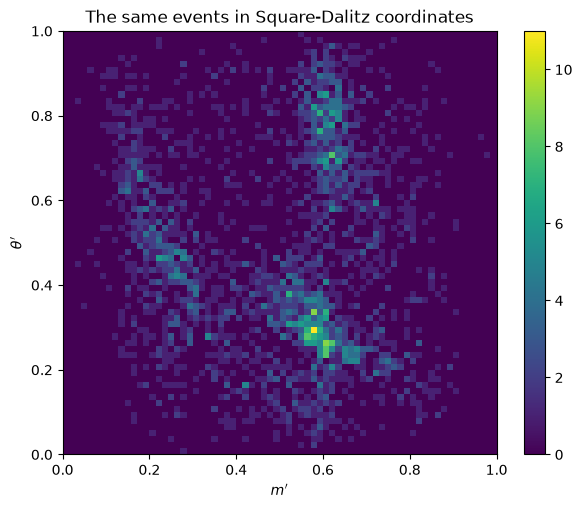

In [5]:
from dalitzplotfitter import plot_dalitz, plot_square_dalitz
plot_dalitz(data, x="s12", y="s13", title="Signal pseudo-data")
plt.show()
plot_square_dalitz(
    data, mother_mass=channel.parent_mass, masses=channel.daughter_masses,
    pair=(0, 1), title="The same events in Square-Dalitz coordinates",
)
plt.show()

The curved kinematic region becomes a square. Coordinate integration requires a
Jacobian, which `SquareDalitzGrid` includes in its weights. Folding is optional for
plots and maps with identical particles; it is not needed to make this unbinned model
symmetric. Here the identical pair is `(1, 2)`, not the resonance pair `(0, 1)`.

## Try it yourself

1. Change the non-resonant coefficient and inspect the interference pattern.
2. Plot `s13` against `s23` and explain the change in axes.
3. Increase the CDF resolution to 768 and compare distributions, not individual events.

## Continue learning

[Next: your first fit](tutorial_02_first_fit.ipynb). Reference: [API catalog](../docs/catalog.md), [Square Dalitz](../docs/square_dalitz.md).

Return to [the course guide](TUTORIALS.md).